## **5° Module**: TT - Quantum Circuit Resource Benchmark
* September 21°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

This notebook measures the **computational ceiling** of the variational quantum
circuits used in Module 5, in order to fix the operating point of the experiment:
the number of qubits `k`, the number of variational layers `reps`, and the number
of `shots`.

Every downstream decision depends on these three numbers. `k` fixes how many
features `SelectKBest` keeps in Module 4, and `reps` together with `shots` fixes
whether training the five experimental conditions is feasible at all.

The benchmark answers five questions:

1. How does circuit **depth** grow with `k` and `reps` after transpilation?
2. What do a **forward** pass and a **parameter-shift backward** pass cost per sample?
3. What does the **fidelity kernel** cost, given its $O(N^2)$ scaling (RNF-06)?
4. How many **shots** are needed for stable expectation values (OE-6)?
5. Is joint quantum-classical training affordable, or must the embedding be precomputed?

Scope note: everything runs on statevector / `AerSimulator` primitives, never on
real quantum hardware, as stated in the framing rules of the project.

> Requirements addressed: **RNF-05** (shots), **RNF-07** (parameterisable circuit),
> **OE-6** (practical limitations of the simulator).

#### **1° Setup & Circuit Construction**

**a.** Import the necessary libraries

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import zz_feature_map, pauli_feature_map, real_amplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.kernels import FidelityQuantumKernel

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

import qiskit, qiskit_aer, qiskit_machine_learning
print("Environment:")
print(f"  qiskit                   : {qiskit.__version__}")
print(f"  qiskit-aer               : {qiskit_aer.__version__}")
print(f"  qiskit-machine-learning  : {qiskit_machine_learning.__version__}")
print(f"  numpy                    : {np.__version__}")

Environment:
  qiskit                   : 2.3.0
  qiskit-aer               : 0.17.2
  qiskit-machine-learning  : 0.9.0
  numpy                    : 2.2.6


**b.** Benchmark configuration

In [2]:
# Global seed: every measurement in this notebook must be reproducible (RNF-01)
SEED = 42
rng = np.random.default_rng(SEED)

# QUICK validates the whole notebook end to end in about a minute.
# Set it to False for the full measurement that goes into the technical report.
QUICK = False

# Search grid. RNF-07 declares k in [8, 16] and reps in [1, 6];
# reps > 3 is not explored because depth already grows linearly with it.
K_VALUES     = [4, 8] if QUICK else [8, 12, 16]
REPS_VALUES  = [1, 2] if QUICK else [1, 2, 3]
FEATURE_MAPS = ["zz", "pauli_z_zz"]

# Timing is measured on a small batch and extrapolated linearly:
# cost per sample is constant, the simulator has no batching advantage here.
N_TIMING = 2 if QUICK else 4

# The fidelity kernel is measured on small N and extrapolated: its cost is
# exactly O(N^2), so a measured per-pair cost determines the whole curve.
N_KERNEL        = [20, 40] if QUICK else [30, 60]
N_KERNEL_TARGET = [150, 200]

# Shots grid for the stability study (RNF-05)
SHOTS_VALUES = [512, 1024, 2048] if QUICK else [512, 1024, 2048, 4096, 8192]

# Real set sizes, taken from the EDA, used for the extrapolation
N_TRAIN = {"mass": 1318, "calcification": 1546}
N_TOTAL = 3568
EPOCHS  = 50

RESULTS_DIR = Path("/Users/alexander_san/TT/Code/results")
RESULTS_DIR.mkdir(exist_ok=True)
OUT_CSV = RESULTS_DIR / "5_benchmark_resultados.csv"

print(f"Benchmark grid configured.   QUICK = {QUICK}")
print(f"  qubits (k)      : {K_VALUES}")
print(f"  variational reps: {REPS_VALUES}")
print(f"  feature maps    : {FEATURE_MAPS}")
print(f"  timing batch    : {N_TIMING} samples")
print(f"  shots grid      : {SHOTS_VALUES}")
if QUICK:
    print()
    print("  NOTE: QUICK mode. Set QUICK = False to produce the numbers cited")
    print("        in the technical report (roughly 40 min).")

Benchmark grid configured.   QUICK = False
  qubits (k)      : [8, 12, 16]
  variational reps: [1, 2, 3]
  feature maps    : ['zz', 'pauli_z_zz']
  timing batch    : 4 samples
  shots grid      : [512, 1024, 2048, 4096, 8192]


**c.** Build the variational circuit

In [3]:
def build_vqc(k: int, reps: int, fmap: str = "zz") -> tuple:
    """
    Build the variational quantum circuit of Module 5: feature map + ansatz.

    Qiskit 2.x deprecates the ZZFeatureMap / PauliFeatureMap / RealAmplitudes
    classes in favour of the equivalent functions, which are used here.

    Parameters
    ----------
    k : int
        Number of qubits, equal to the number of selected features.
    reps : int
        Number of repetitions of the RealAmplitudes variational layer.
    fmap : str
        Either "zz" (ZZFeatureMap) or "pauli_z_zz" (PauliFeatureMap with Z, ZZ).

    Returns
    -------
    tuple
        (circuit, input_params, weight_params)
    """
    if fmap == "zz":
        feature_map = zz_feature_map(k, reps=1)
    elif fmap == "pauli_z_zz":
        feature_map = pauli_feature_map(k, reps=1, paulis=["Z", "ZZ"])
    else:
        raise ValueError(f"Unknown feature map: {fmap}")

    ansatz = real_amplitudes(k, reps=reps)

    circuit = QuantumCircuit(k)
    circuit.compose(feature_map, inplace=True)
    circuit.compose(ansatz, inplace=True)

    return circuit, list(feature_map.parameters), list(ansatz.parameters)


def z_observables(k: int) -> list:
    """
    Build the single-qubit Z observables whose expectation values form the
    quantum embedding <Z_i> in [-1, 1]^k.
    """
    return [SparsePauliOp.from_sparse_list([("Z", [i], 1.0)], num_qubits=k)
            for i in range(k)]


print("Circuit builders defined.")

Circuit builders defined.


**d.** Inspect one circuit

Sanity check on a small circuit (k=4, reps=1, ZZFeatureMap)
  qubits            : 4
  input parameters  : 4   (one per feature)
  weight parameters : 8   (expected (reps+1)*k = 8)
  raw depth         : 22


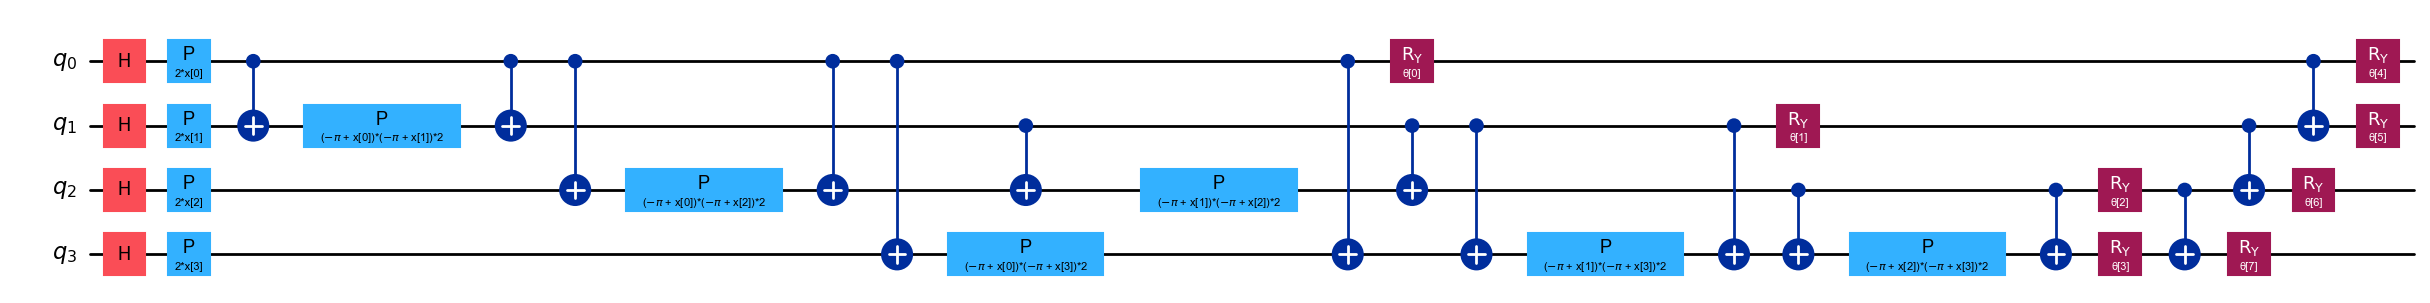

In [4]:
qc, in_p, w_p = build_vqc(k=4, reps=1, fmap="zz")

print("Sanity check on a small circuit (k=4, reps=1, ZZFeatureMap)")
print(f"  qubits            : {qc.num_qubits}")
print(f"  input parameters  : {len(in_p)}   (one per feature)")
print(f"  weight parameters : {len(w_p)}   (expected (reps+1)*k = {(1 + 1) * 4})")
print(f"  raw depth         : {qc.depth()}")

qc.draw("mpl", fold=40)

#### **2° Circuit Complexity Analysis**

**a.** Depth and gate count after transpilation

Raw depth is misleading: the feature map and the ansatz use gates that no real
backend implements natively. Everything is transpiled to a standard basis so the
numbers reflect actual circuit cost.

In [5]:
BASIS = ["rz", "sx", "x", "cx"]

records = []
for fmap in FEATURE_MAPS:
    for k in K_VALUES:
        for reps in REPS_VALUES:
            qc, in_p, w_p = build_vqc(k, reps, fmap)
            tqc = transpile(qc, basis_gates=BASIS, optimization_level=1,
                            seed_transpiler=SEED)
            records.append({
                "feature_map": fmap,
                "k": k,
                "reps": reps,
                "n_weights": len(w_p),
                "depth_raw": qc.depth(),
                "depth_transpiled": tqc.depth(),
                "n_cx": tqc.count_ops().get("cx", 0),
                "n_gates": sum(tqc.count_ops().values()),
            })

complexity = pd.DataFrame(records)
print(f"Transpiled {len(complexity)} configurations to basis {BASIS}")
complexity

Transpiled 18 configurations to basis ['rz', 'sx', 'x', 'cx']


,feature_map,k,reps,n_weights,depth_raw,depth_transpiled,n_cx,n_gates
0,zz,8,1,16,50,58,63,187
1,zz,8,2,24,53,64,70,226
2,zz,8,3,32,56,70,77,265
3,zz,12,1,24,78,86,143,353
4,zz,12,2,36,81,92,154,412
5,zz,12,3,48,84,98,165,471
6,zz,16,1,32,106,114,255,567
7,zz,16,2,48,109,120,270,646
8,zz,16,3,64,112,126,285,725
9,pauli_z_zz,8,1,16,50,58,63,187


**b.** Visualization

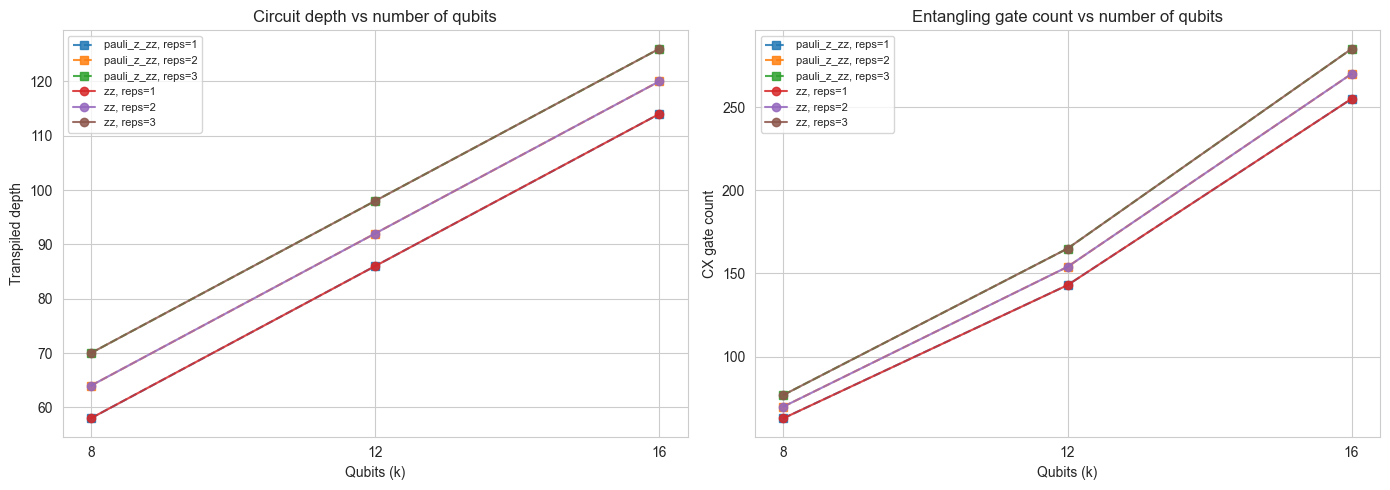

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fmap, grp in complexity.groupby("feature_map"):
    for reps, sub in grp.groupby("reps"):
        style = "-o" if fmap == "zz" else "--s"
        axes[0].plot(sub["k"], sub["depth_transpiled"], style,
                     label=f"{fmap}, reps={reps}", alpha=0.85)
        axes[1].plot(sub["k"], sub["n_cx"], style,
                     label=f"{fmap}, reps={reps}", alpha=0.85)

axes[0].set_xlabel("Qubits (k)")
axes[0].set_ylabel("Transpiled depth")
axes[0].set_title("Circuit depth vs number of qubits")
axes[1].set_xlabel("Qubits (k)")
axes[1].set_ylabel("CX gate count")
axes[1].set_title("Entangling gate count vs number of qubits")
for ax in axes:
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/Users/alexander_san/TT/Docs/Figures/E1_circuit_complexity.png",
            dpi=150, bbox_inches="tight")
plt.show()

**c.** Summary

In [7]:
print("=" * 55)
print("CIRCUIT COMPLEXITY SUMMARY")
print("=" * 55)
k_lo, k_hi = min(K_VALUES), max(K_VALUES)
for fmap in FEATURE_MAPS:
    sub = complexity[(complexity.feature_map == fmap) & (complexity.reps == 1)]
    print(f"  {fmap}")
    print(f"    depth  k={k_lo} .. {k_hi} (reps=1) : "
          f"{sub[sub.k == k_lo].depth_transpiled.iloc[0]:>5d} -> "
          f"{sub[sub.k == k_hi].depth_transpiled.iloc[0]:>5d}")
    print(f"    CX     k={k_lo} .. {k_hi} (reps=1) : "
          f"{sub[sub.k == k_lo].n_cx.iloc[0]:>5d} -> "
          f"{sub[sub.k == k_hi].n_cx.iloc[0]:>5d}")
print()
print("  The PauliFeatureMap with (Z, ZZ) is structurally equivalent to the")
print("  ZZFeatureMap: both encode first and second order terms, so any")
print("  difference in results comes from the encoding angles, not from cost.")
print("=" * 55)

CIRCUIT COMPLEXITY SUMMARY
  zz
    depth  k=8 .. 16 (reps=1) :    58 ->   114
    CX     k=8 .. 16 (reps=1) :    63 ->   255
  pauli_z_zz
    depth  k=8 .. 16 (reps=1) :    58 ->   114
    CX     k=8 .. 16 (reps=1) :    63 ->   255

  The PauliFeatureMap with (Z, ZZ) is structurally equivalent to the
  ZZFeatureMap: both encode first and second order terms, so any
  difference in results comes from the encoding angles, not from cost.


#### **3° Forward & Backward Timing**

**a.** Build the QNN

`input_gradients=False` because the feature vector reaches the circuit straight
from Module 4, with no trainable classical layer before it. Nothing upstream
consumes $\partial f / \partial x$, so computing it would be wasted work.

The saving is larger than parameter counting suggests. A naive estimate gives
$2p$ circuit evaluations for the weights against $2(k + p)$ for weights and
inputs together, i.e. about a third. Measured, it is 36-70 % depending on `k`
and `reps`, because the inputs do **not** enter as plain single-parameter
rotations: the ZZFeatureMap entangling layer encodes the product
$(\pi - x_i)(\pi - x_j)$, so each $x_i$ appears in one rotation plus $k-1$
entangling terms and its derivative needs the chain rule across all of them.

In [8]:
def make_qnn(k: int, reps: int, fmap: str, estimator=None) -> EstimatorQNN:
    """
    Wrap the variational circuit into an EstimatorQNN producing <Z_i> in [-1,1]^k.

    Parameters
    ----------
    k, reps, fmap : see build_vqc
    estimator : BaseEstimatorV2, optional
        Defaults to the exact statevector estimator (no sampling noise).

    Returns
    -------
    EstimatorQNN
    """
    qc, in_p, w_p = build_vqc(k, reps, fmap)
    return EstimatorQNN(
        circuit=qc,
        input_params=in_p,
        weight_params=w_p,
        observables=z_observables(k),
        estimator=estimator if estimator is not None else StatevectorEstimator(),
        input_gradients=False,
    )


print("QNN factory defined.")

QNN factory defined.


**b.** Benchmark forward and backward passes

Exact expectation values are used here. Shots are reserved for the sensitivity
study in section 5: sampling noise would corrupt a timing measurement without
changing the conclusion about feasibility.

In [9]:
timing = []
print(f"Timing forward/backward on {N_TIMING} samples per configuration...")
print()

for fmap in FEATURE_MAPS:
    for k in K_VALUES:
        for reps in REPS_VALUES:
            qnn = make_qnn(k, reps, fmap)
            X = rng.uniform(0, np.pi, (N_TIMING, k))
            w = rng.uniform(0, 2 * np.pi, qnn.num_weights)

            qnn.forward(X[:1], w)                       # warm-up, excluded

            t0 = time.perf_counter()
            qnn.forward(X, w)
            t_fwd = time.perf_counter() - t0

            t0 = time.perf_counter()
            qnn.backward(X, w)
            t_bwd = time.perf_counter() - t0

            timing.append({
                "feature_map": fmap, "k": k, "reps": reps,
                "n_weights": qnn.num_weights,
                "fwd_per_sample_s": t_fwd / N_TIMING,
                "bwd_per_sample_s": t_bwd / N_TIMING,
            })
            print(f"  {fmap:11s} k={k:2d} reps={reps}  "
                  f"fwd {t_fwd / N_TIMING * 1000:8.2f} ms/sample  "
                  f"bwd {t_bwd / N_TIMING * 1000:10.2f} ms/sample")

timing = pd.DataFrame(timing)
print()
print("Done.")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Timing forward/backward on 4 samples per configuration...



No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  zz          k= 8 reps=1  fwd    16.58 ms/sample  bwd     587.40 ms/sample


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


...

  pauli_z_zz  k=12 reps=3  fwd   120.57 ms/sample  bwd   11633.90 ms/sample


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  pauli_z_zz  k=16 reps=1  fwd  1072.65 ms/sample  bwd   74508.04 ms/sample


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  pauli_z_zz  k=16 reps=2  fwd  2001.84 ms/sample  bwd  144944.62 ms/sample
  pauli_z_zz  k=16 reps=3  fwd  1898.30 ms/sample  bwd  215266.69 ms/sample

Done.


**c.** Extrapolation to the full training set

One training step costs one forward plus one backward pass per sample. The table
below projects that onto the real subsets over `EPOCHS` epochs, which is what
actually decides whether a configuration is usable.

In [10]:
timing["step_per_sample_s"] = timing.fwd_per_sample_s + timing.bwd_per_sample_s

for subset, n in N_TRAIN.items():
    timing[f"train_{subset}_h"] = timing.step_per_sample_s * n * EPOCHS / 3600

timing["total_both_h"] = timing.train_mass_h + timing.train_calcification_h

print(f"Projected training cost ({EPOCHS} epochs, mass n={N_TRAIN['mass']}, "
      f"calc n={N_TRAIN['calcification']})")
(timing[["feature_map", "k", "reps", "n_weights", "step_per_sample_s",
         "train_mass_h", "train_calcification_h", "total_both_h"]]
 .sort_values("total_both_h")
 .round(4))

Projected training cost (50 epochs, mass n=1318, calc n=1546)


,feature_map,k,reps,n_weights,step_per_sample_s,train_mass_h,train_calcification_h,total_both_h
9,pauli_z_zz,8,1,16,0.5798,10.6129,12.4488,23.0618
0,zz,8,1,16,0.6040,11.0562,12.9688,24.0250
10,pauli_z_zz,8,2,24,0.9450,17.2995,20.2921,37.5916
1,zz,8,2,24,0.9960,18.2315,21.3854,39.6169
11,pauli_z_zz,8,3,32,1.3685,25.0514,29.3850,54.4364
2,zz,8,3,32,1.3983,25.5971,30.0252,55.6223
12,pauli_z_zz,12,1,24,4.5391,83.0904,97.4642,180.5546
3,zz,12,1,24,4.7982,87.8346,103.0290,190.8636
4,zz,12,2,36,7.4586,136.5337,160.1526,296.6862
13,pauli_z_zz,12,2,36,7.5259,137.7657,161.5978,299.3635


**d.** Visualization

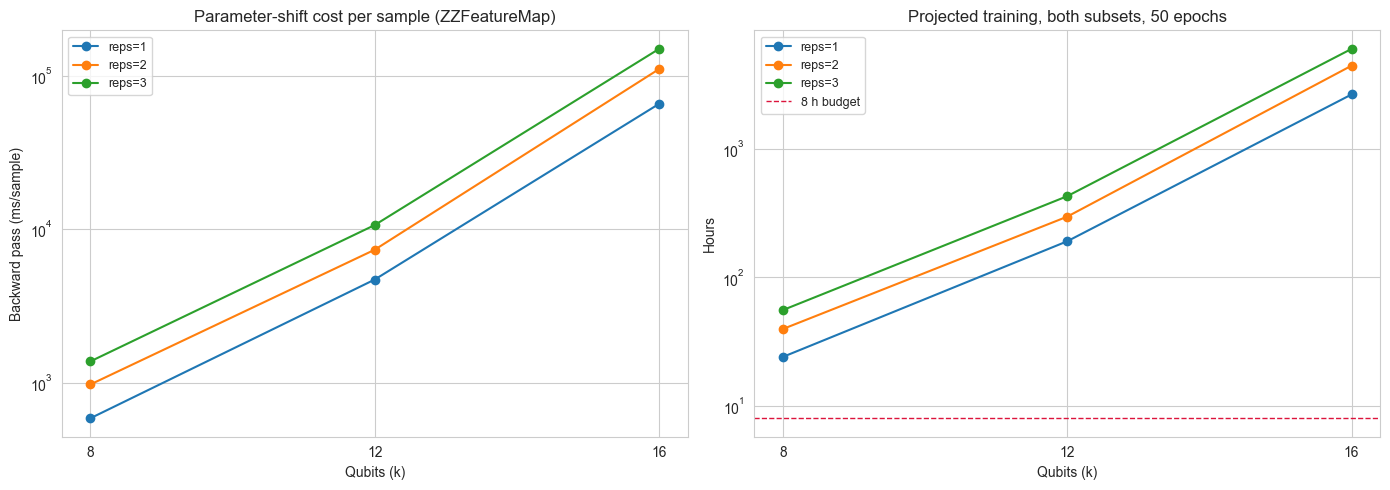

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

zz = timing[timing.feature_map == "zz"]
for reps, sub in zz.groupby("reps"):
    axes[0].plot(sub["k"], sub["bwd_per_sample_s"] * 1000, "-o", label=f"reps={reps}")
    axes[1].plot(sub["k"], sub["total_both_h"], "-o", label=f"reps={reps}")

axes[0].set_xlabel("Qubits (k)")
axes[0].set_ylabel("Backward pass (ms/sample)")
axes[0].set_title("Parameter-shift cost per sample (ZZFeatureMap)")
axes[0].set_yscale("log")

axes[1].axhline(8, color="crimson", ls="--", lw=1, label="8 h budget")
axes[1].set_xlabel("Qubits (k)")
axes[1].set_ylabel("Hours")
axes[1].set_title(f"Projected training, both subsets, {EPOCHS} epochs")
axes[1].set_yscale("log")

for ax in axes:
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/Users/alexander_san/TT/Docs/Figures/E2_training_cost.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### **4° Fidelity Kernel Cost**

**a.** Kernel matrix timing

The separability metrics (KTA and the geometric difference) are computed on the
quantum kernel $K_Q(x, x') = |\langle \phi(x) | \phi(x') \rangle|^2$, not on the
$\langle Z_i \rangle$ vectors. That kernel uses the **feature map only**, with no
variational layer, which is also what keeps the comparison against the
unsupervised classical baselines fair.

Its cost is $O(N^2)$, which is why RNF-06 caps the sub-sample at 150-200 cases
per subset. A measured per-pair cost is enough to project the whole curve.

In [12]:
kernel_timing = []
print("Timing fidelity kernel (feature map only, no ansatz)...")
print()

for fmap in FEATURE_MAPS:
    for k in K_VALUES:
        fm = (zz_feature_map(k, reps=1) if fmap == "zz"
              else pauli_feature_map(k, reps=1, paulis=["Z", "ZZ"]))
        qk = FidelityQuantumKernel(feature_map=fm)
        for n in N_KERNEL:
            X = rng.uniform(0, np.pi, (n, k))
            t0 = time.perf_counter()
            K = qk.evaluate(X)
            dt = time.perf_counter() - t0
            pairs = n * (n - 1) // 2
            diag_ok = bool(np.allclose(np.diag(K), 1.0, atol=1e-6))
            kernel_timing.append({"feature_map": fmap, "k": k, "n_samples": n,
                                  "seconds": dt, "n_pairs": pairs,
                                  "s_per_pair": dt / pairs, "diag_ok": diag_ok})
            print(f"  {fmap:11s} k={k:2d}  N={n:3d}  {dt:7.2f} s"
                  f"   ({dt / pairs * 1000:6.2f} ms/pair, diag==1: {diag_ok})")

kernel_timing = pd.DataFrame(kernel_timing)

proj = []
for (fmap, k), grp in kernel_timing.groupby(["feature_map", "k"]):
    cost = grp.s_per_pair.mean()
    for n in N_KERNEL_TARGET:
        proj.append({"feature_map": fmap, "k": k, "n_samples": n,
                     "projected_s": cost * n * (n - 1) / 2})
kernel_proj = pd.DataFrame(proj)

print()
print("Projected to the RNF-06 sub-sample sizes:")
kernel_proj.pivot_table(index=["feature_map", "k"], columns="n_samples",
                        values="projected_s").round(1)

Timing fidelity kernel (feature map only, no ansatz)...

  zz          k= 8  N= 30     5.29 s   ( 12.15 ms/pair, diag==1: True)
  zz          k= 8  N= 60    22.44 s   ( 12.68 ms/pair, diag==1: True)
  zz          k=12  N= 30    58.65 s   (134.82 ms/pair, diag==1: True)
  zz          k=12  N= 60   256.67 s   (145.01 ms/pair, diag==1: True)
  zz          k=16  N= 30   830.01 s   (1908.07 ms/pair, diag==1: True)
  zz          k=16  N= 60  3110.44 s   (1757.31 ms/pair, diag==1: True)
  pauli_z_zz  k= 8  N= 30     4.72 s   ( 10.85 ms/pair, diag==1: True)
  pauli_z_zz  k= 8  N= 60    19.36 s   ( 10.94 ms/pair, diag==1: True)
  pauli_z_zz  k=12  N= 30    47.32 s   (108.79 ms/pair, diag==1: True)
  pauli_z_zz  k=12  N= 60   191.96 s   (108.45 ms/pair, diag==1: True)
  pauli_z_zz  k=16  N= 30   717.73 s   (1649.94 ms/pair, diag==1: True)
  pauli_z_zz  k=16  N= 60  3011.63 s   (1701.49 ms/pair, diag==1: True)

Projected to the RNF-06 sub-sample sizes:


n_samples           150      200
feature_map k                   
pauli_z_zz  8     121.7    216.8
            12   1213.9   2161.6
            16  18726.1  33346.8
zz          8     138.7    247.1
            12   1563.6   2784.4
            16  20480.3  36470.5

**b.** Summary

In [13]:
print("=" * 55)
print("FIDELITY KERNEL COST (projected, N = 200 per subset)")
print("=" * 55)
sub = kernel_proj[kernel_proj.n_samples == 200]
for _, r in sub.iterrows():
    print(f"  {r.feature_map:11s} k={int(r.k):2d} : {r.projected_s:8.1f} s")
print()
print("  Four matrices are needed in total: 2 feature maps x 2 subsets.")
worst_k = sub.groupby("k").projected_s.sum().max()
print(f"  Worst case for a single k, all four matrices: {worst_k * 2 / 60:.1f} min")
print()
print(f"  All kernel diagonals equal 1: {bool(kernel_timing.diag_ok.all())}")
print("=" * 55)

FIDELITY KERNEL COST (projected, N = 200 per subset)
  pauli_z_zz  k= 8 :    216.8 s
  pauli_z_zz  k=12 :   2161.6 s
  pauli_z_zz  k=16 :  33346.8 s
  zz          k= 8 :    247.1 s
  zz          k=12 :   2784.4 s
  zz          k=16 :  36470.5 s

  Four matrices are needed in total: 2 feature maps x 2 subsets.
  Worst case for a single k, all four matrices: 2327.2 min

  All kernel diagonals equal 1: True


#### **5° Shots Sensitivity**

**a.** Stability of the expectation values

The Aer estimator is a V2 primitive: it takes a target `precision` rather than a
shot count, related by $\text{precision} = 1/\sqrt{\text{shots}}$.

What matters is how far a shot-based $\langle Z_i \rangle$ deviates from the exact
statevector value. That deviation is noise injected straight into the embedding,
and it propagates into every separability metric downstream.

> This section produces the quantitative evidence required by **OE-6**.

In [14]:
K_SHOTS = min(8, max(K_VALUES))
REPS_SHOTS = 1
X_shots = rng.uniform(0, np.pi, (16, K_SHOTS))
w_shots = rng.uniform(0, 2 * np.pi, (REPS_SHOTS + 1) * K_SHOTS)

exact = make_qnn(K_SHOTS, REPS_SHOTS, "zz").forward(X_shots, w_shots)

shots_records = []
print(f"Comparing shot-based estimates against exact values (k={K_SHOTS})")
print()
for shots in SHOTS_VALUES:
    est = AerEstimator(options={"default_precision": 1.0 / np.sqrt(shots)})
    qnn = make_qnn(K_SHOTS, REPS_SHOTS, "zz", estimator=est)

    t0 = time.perf_counter()
    approx = qnn.forward(X_shots, w_shots)
    dt = (time.perf_counter() - t0) / len(X_shots)

    err = np.abs(approx - exact)
    shots_records.append({"shots": shots, "mae": err.mean(),
                          "max_err": err.max(), "fwd_per_sample_s": dt})
    print(f"  shots={shots:5d}  MAE={err.mean():.5f}  max={err.max():.5f}"
          f"  {dt * 1000:7.2f} ms/sample")

shots_df = pd.DataFrame(shots_records)
print()
print("Done.")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Comparing shot-based estimates against exact values (k=8)

  shots=  512  MAE=0.02025  max=0.08364     8.01 ms/sample


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  shots= 1024  MAE=0.01935  max=0.06559     4.32 ms/sample
  shots= 2048  MAE=0.01613  max=0.06523     4.37 ms/sample
  shots= 4096  MAE=0.01990  max=0.08708     4.00 ms/sample
  shots= 8192  MAE=0.01784  max=0.06885     4.49 ms/sample

Done.


**b.** Visualization

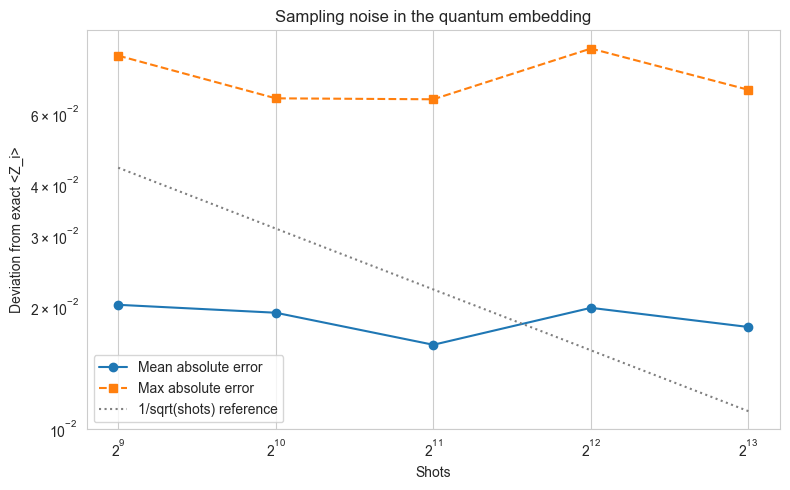

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(shots_df.shots, shots_df.mae, "-o", label="Mean absolute error")
ax.plot(shots_df.shots, shots_df.max_err, "--s", label="Max absolute error")
ax.plot(shots_df.shots, 1 / np.sqrt(shots_df.shots), ":", color="gray",
        label="1/sqrt(shots) reference")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Shots")
ax.set_ylabel("Deviation from exact <Z_i>")
ax.set_title("Sampling noise in the quantum embedding")
ax.legend()
plt.tight_layout()
plt.savefig("/Users/alexander_san/TT/Docs/Figures/E3_shots_sensitivity.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### **6° Architecture Decision: Joint Training vs Precomputed Embedding**

**a.** The two candidate architectures

The methodology of Module 6 specifies that conditions C4 and C5 integrate the
circuit with the MLP through `TorchConnector`, so that the variational parameters
$\theta$ and the MLP weights are optimised **jointly**. Section 3 measured what
that costs.

There is a second architecture worth pricing. If $\theta$ stays **fixed**, the
circuit becomes a deterministic feature transformation: the embeddings
$\langle Z_i \rangle$ are computed once for the whole dataset, cached, and the MLP
trains on them as ordinary classical vectors.

| | Architecture A - joint training | Architecture B - precomputed embedding |
|---|---|---|
| $\theta$ | trainable, parameter-shift | fixed (random seed, or feature map only) |
| Circuit calls | every sample, every epoch | once per sample, total |
| MLP input | output of a live quantum layer | a cached matrix |

The comparison is not only about speed. Architecture B is also what makes the
comparison against C2 and C3 fair: those two classical baselines are
**unsupervised**, so letting the quantum condition fit $\theta$ against the labels
would grant it an advantage the baselines never had.

In [16]:
arch = []
print("Pricing Architecture B (fixed theta, embeddings computed once)...")
print()

for k in K_VALUES:
    qnn = make_qnn(k, reps=1, fmap="zz")
    w = rng.uniform(0, 2 * np.pi, qnn.num_weights)
    X = rng.uniform(0, np.pi, (16, k))
    qnn.forward(X[:1], w)                                  # warm-up

    t0 = time.perf_counter()
    qnn.forward(X, w)
    fwd = (time.perf_counter() - t0) / len(X)

    # Architecture B: both feature maps, whole dataset, one single pass
    hours_B = fwd * N_TOTAL * 2 / 3600
    # Architecture A: C4 and C5, both subsets, EPOCHS epochs
    hours_A = timing[(timing.k == k) & (timing.reps == 1) &
                     (timing.feature_map == "zz")].total_both_h.iloc[0] * 2

    arch.append({"k": k, "fwd_ms": fwd * 1000,
                 "arch_A_hours": hours_A, "arch_B_hours": hours_B,
                 "speedup": hours_A / hours_B})
    print(f"  k={k:2d}  A (joint) {hours_A:10.2f} h   "
          f"B (precomputed) {hours_B:7.3f} h   speedup {hours_A / hours_B:8.0f}x")

arch = pd.DataFrame(arch)
print()
print("Architecture A covers C4 and C5 on both subsets over all epochs;")
print("Architecture B covers both feature maps over the entire dataset, once.")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Pricing Architecture B (fixed theta, embeddings computed once)...



No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  k= 8  A (joint)      48.05 h   B (precomputed)   0.033 h   speedup     1472x


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  k=12  A (joint)     381.73 h   B (precomputed)   0.199 h   speedup     1916x
  k=16  A (joint)    5304.19 h   B (precomputed)   2.461 h   speedup     2155x

Architecture A covers C4 and C5 on both subsets over all epochs;
Architecture B covers both feature maps over the entire dataset, once.


#### **7° Conclusions: Operating Point**

In [17]:
BUDGET_H = 8.0   # hours available for the quantum stage

print("=" * 66)
print("BENCHMARK SUMMARY - OPERATING POINT")
print("=" * 66)
print(f"  Configurations timed : {len(timing)}")
print(f"  Budget assumed       : {BUDGET_H:.0f} h for the quantum stage")
print()

print("  ARCHITECTURE A - joint training via TorchConnector (current M6 design)")
viable_A = timing[timing.total_both_h * 2 <= BUDGET_H]
for _, r in timing[(timing.feature_map == "zz") & (timing.reps == 1)].iterrows():
    flag = "within budget" if r.total_both_h * 2 <= BUDGET_H else "NOT FEASIBLE"
    print(f"    k={int(r.k):2d} reps=1 : {r.total_both_h * 2:12.2f} h   {flag}")
print(f"    -> {len(viable_A)} of {len(timing)} configurations fit the budget")
print()

print("  ARCHITECTURE B - fixed theta, embeddings precomputed once")
for _, r in arch.iterrows():
    print(f"    k={int(r.k):2d}        : {r.arch_B_hours:12.3f} h   "
          f"({r.speedup:.0f}x cheaper)")
print()

print("  CONSEQUENCE")
print("    Joint training does not scale. RNF-07 declares k in [8, 16], but the")
print("    upper half of that range is unreachable under Architecture A.")
print("    Architecture B keeps the whole declared range open, and is also the")
print("    architecture that keeps the comparison against C2 and C3 fair, since")
print("    those baselines are unsupervised.")
print()
print("  Shots: training uses exact statevector expectation values; the shots")
print("  grid in section 5 documents sampling noise for OE-6 only.")
print("=" * 66)

# Persist every measurement: these numbers are cited in the technical report
timing.to_csv(OUT_CSV, index=False)
complexity.to_csv(OUT_CSV.with_name("5_benchmark_complejidad.csv"), index=False)
kernel_timing.to_csv(OUT_CSV.with_name("5_benchmark_kernel.csv"), index=False)
kernel_proj.to_csv(OUT_CSV.with_name("5_benchmark_kernel_proyeccion.csv"), index=False)
shots_df.to_csv(OUT_CSV.with_name("5_benchmark_shots.csv"), index=False)
arch.to_csv(OUT_CSV.with_name("5_benchmark_arquitectura.csv"), index=False)
print()
print(f"Results written next to {OUT_CSV.name}")

BENCHMARK SUMMARY - OPERATING POINT
  Configurations timed : 18
  Budget assumed       : 8 h for the quantum stage

  ARCHITECTURE A - joint training via TorchConnector (current M6 design)
    k= 8 reps=1 :        48.05 h   NOT FEASIBLE
    k=12 reps=1 :       381.73 h   NOT FEASIBLE
    k=16 reps=1 :      5304.19 h   NOT FEASIBLE
    -> 0 of 18 configurations fit the budget

  ARCHITECTURE B - fixed theta, embeddings precomputed once
    k= 8        :        0.033 h   (1472x cheaper)
    k=12        :        0.199 h   (1916x cheaper)
    k=16        :        2.461 h   (2155x cheaper)

  CONSEQUENCE
    Joint training does not scale. RNF-07 declares k in [8, 16], but the
    upper half of that range is unreachable under Architecture A.
    Architecture B keeps the whole declared range open, and is also the
    architecture that keeps the comparison against C2 and C3 fair, since
    those baselines are unsupervised.

  Shots: training uses exact statevector expectation values; the shots